In [90]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder, TargetEncoder
from sklearn.metrics import (
    r2_score,
     mean_absolute_error,
     mean_squared_error
     )
#from sklearn.linear_model import LinearRegression
# from keras.models import Sequential
# from keras.layers import Input, Dense



In [93]:
SEED = 42

def set_global_seed(seed=SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"
    os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
    import tensorflow as tf
    tf.random.set_seed(seed)

set_global_seed(SEED)

In [94]:
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
from keras.models import Sequential
from keras.layers import Input, Dense

In [95]:
data = pd.read_csv("data/salary_dataset.csv")
print(data.shape)
data.dtypes

(30, 2)


YearsExperience    float64
Salary             float64
dtype: object

In [96]:
data.head(3)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0


In [97]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

In [99]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

In [100]:
# EDA
# 1. Outliers Detection - IQR Method
# 2. Noise Analysis - Scaling
# 3. Distribution Analysis - Normal Distribution, Skewness, Kurtosis
# 4. Correlation Analysis - Heatmap, Pairplot, Scatter Plot

In [101]:
# DL DECISION FRAMEWORK
# Rule 1. Dataset Size - 30 total, ~24 after val_split
# Rule 2. Data Complexity - Regularization + Dropout + Learning Rate
# Small dataset requires L2 regularization and dropout to prevent overfitting

In [102]:
model = Sequential([
    Input(shape=(1,)),
    Dense(units=16, activation="relu", kernel_regularizer=keras.regularizers.L2(0.01)),
    keras.layers.Dropout(0.2),
    Dense(units=8, activation="relu", kernel_regularizer=keras.regularizers.L2(0.01)),
    Dense(units=1, activation="linear")
], name="Linear_Regression_Model")
model.summary()

Model: "Linear_Regression_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177 (708.00 B)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

In [103]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    verbose=1,
    restore_best_weights=True,
)

In [104]:
# Alternative model config for reference:
# - Increase units for more complex data
# - Adjust L2 regularization strength (0.01 is moderate)
# - Adjust dropout rate (0.2 = 20% of neurons disabled during training)

In [105]:
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=500,
    validation_split=0.2,
    verbose=1,
    callbacks=[callback]
)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step - loss: 1.1436 - mae: 0.9137 - val_loss: 0.5386 - val_mae: 0.6353
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.1543 - mae: 0.9087 - val_loss: 0.5330 - val_mae: 0.6312
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.1132 - mae: 0.9136 - val_loss: 0.5278 - val_mae: 0.6274
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.0927 - mae: 0.8904 - val_loss: 0.5225 - val_mae: 0.6235
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.0947 - mae: 0.8862 - val_loss: 0.5173 - val_mae: 0.6196
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.0441 - mae: 0.8701 - val_loss: 0.5122 - val_mae: 0.6158
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.0937 - mae: 0.9010 - val_loss: 0.5072 - val_mae: 0.6120
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.0838 - mae: 0.8972 - val_loss: 0.5022 - val_mae: 0.6082
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.0717 - mae:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


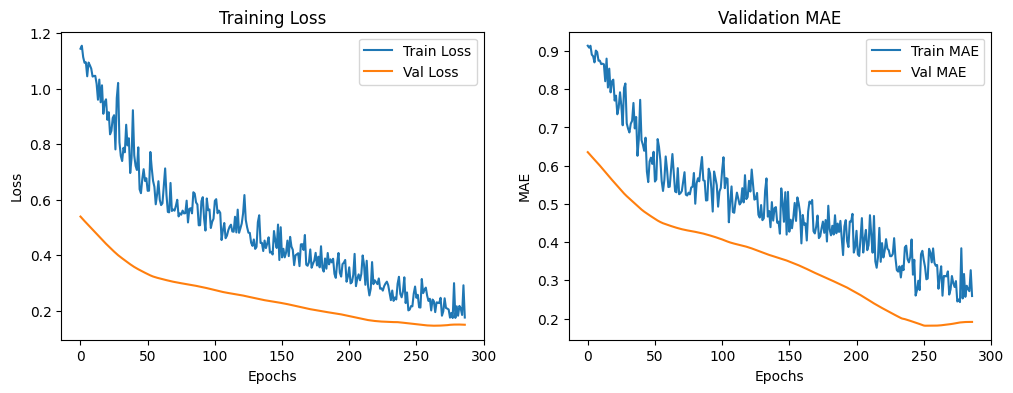

In [106]:
# Inverse transform predictions back to original scale
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["mae"], label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("Validation MAE")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MAE")
axes[1].legend()

In [107]:
# Evaluate on test set (original scale)
print("=" * 50)
print("TEST SET METRICS")
print("=" * 50)
print(f"R2 Score  : {r2_score(y_test, y_pred):.6f}")
print(f"MSE       : {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE       : {mean_absolute_error(y_test, y_pred):.2f}")

TEST SET METRICS
R2 Score  : 0.890127
MSE       : 56122738.21
RMSE      : 7491.51
MAE       : 5927.43


In [108]:
# Evaluate on training set
y_pred_train = scaler_y.inverse_transform(
    model.predict(X_train_scaled).reshape(-1, 1)
).flatten()

print("=" * 50)
print("TRAINING SET METRICS")
print("=" * 50)
print(f"R2 Score  : {r2_score(y_train, y_pred_train):.6f}")
print(f"MSE       : {mean_squared_error(y_train, y_pred_train):.2f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"MAE       : {mean_absolute_error(y_train, y_pred_train):.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
TRAINING SET METRICS
R2 Score  : 0.918330
MSE       : 62421151.90
RMSE      : 7900.71
MAE       : 6003.62


## Summary: Deep Learning vs sklearn Linear Regression

| Aspect | sklearn LinearRegression | Keras Neural Network |
|--------|-------------------------|---------------------|
| Training samples needed | Fewer (works with small data) | More (30 is very small) |
| Regularization | Limited | L1, L2, Dropout |
| Interpretability | High (coefficients) | Low (black box) |
| Flexibility | Low (linear only) | High (any function) |
| Overfitting risk | Low | High (needs regularization) |

**Conclusion**: For this tiny dataset (30 samples), sklearn LinearRegression is more appropriate. Neural networks shine with larger datasets.

In [109]:
# Linear Regression with Deep Learning using Keras 3